In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import re
from plot_functions import plot_condition_boxplots, plot_condition_boxplots_grid
from plot_functions import plot_preference_ratio_by_reward, plot_penalty_vs_no_penalty_metric

# Define Path to results folder
results_path = Path("../Results/Drugs_Energy_Yes_Penalty_G1")

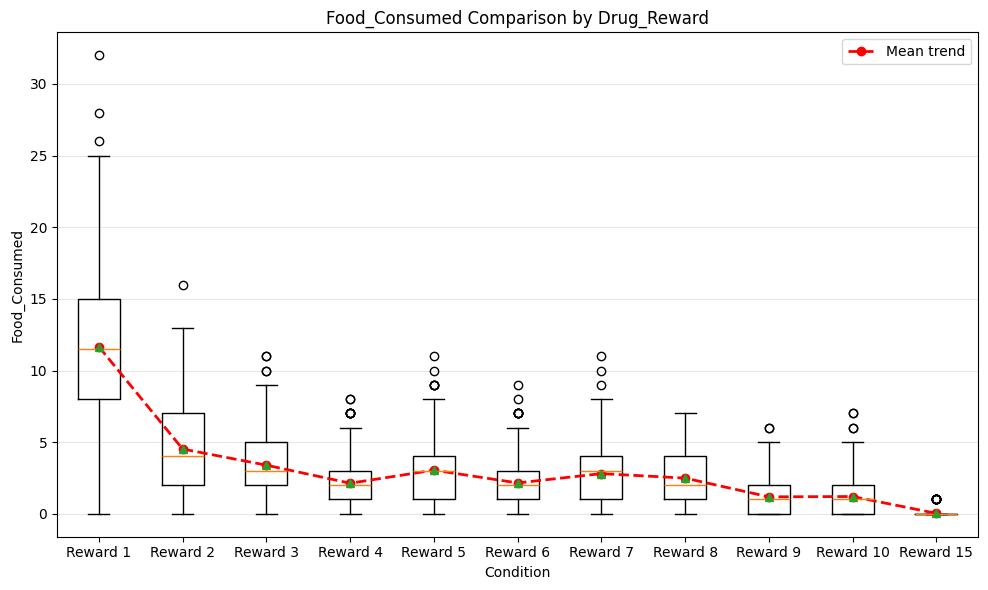

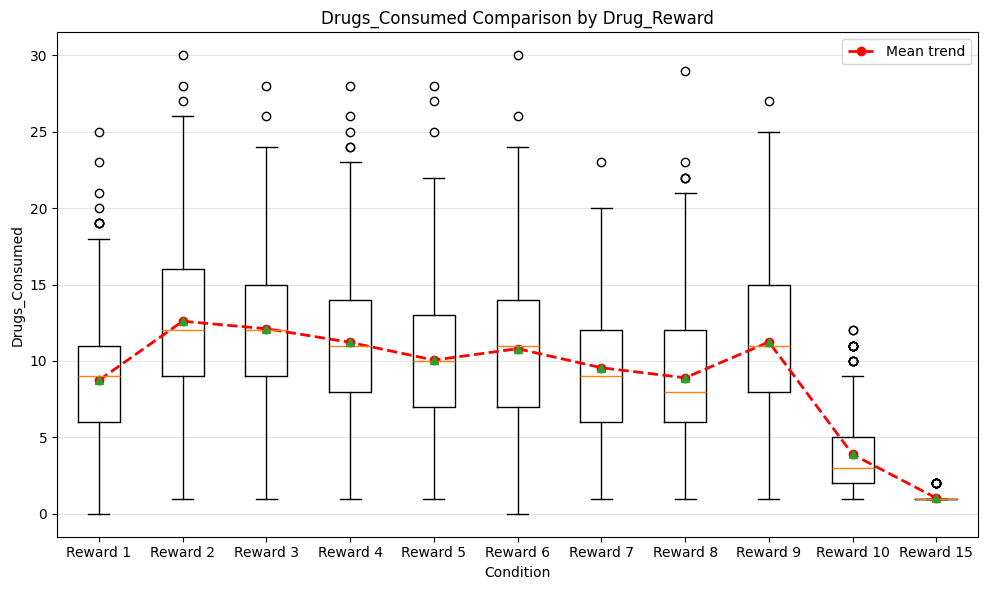

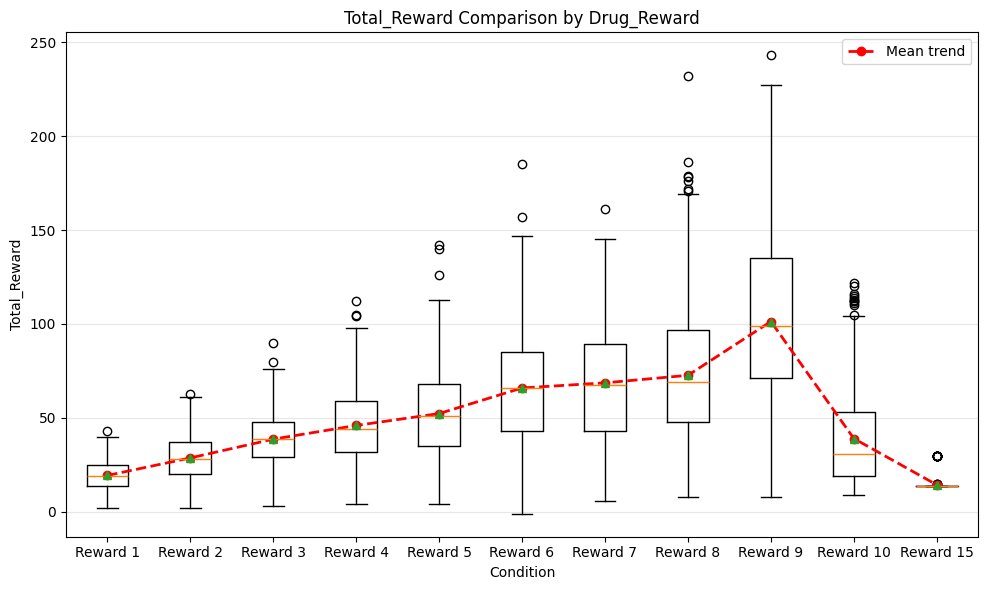

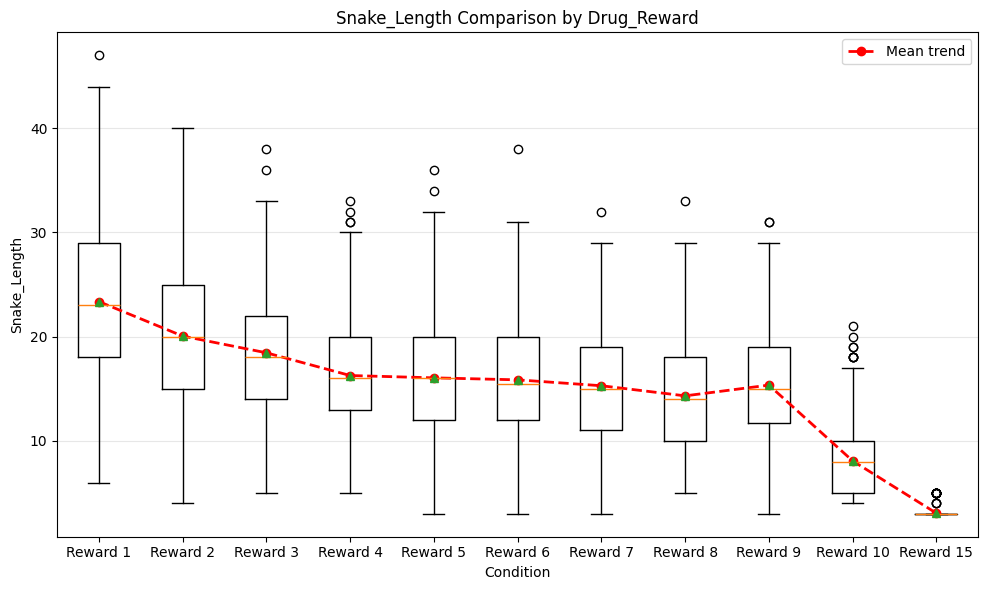

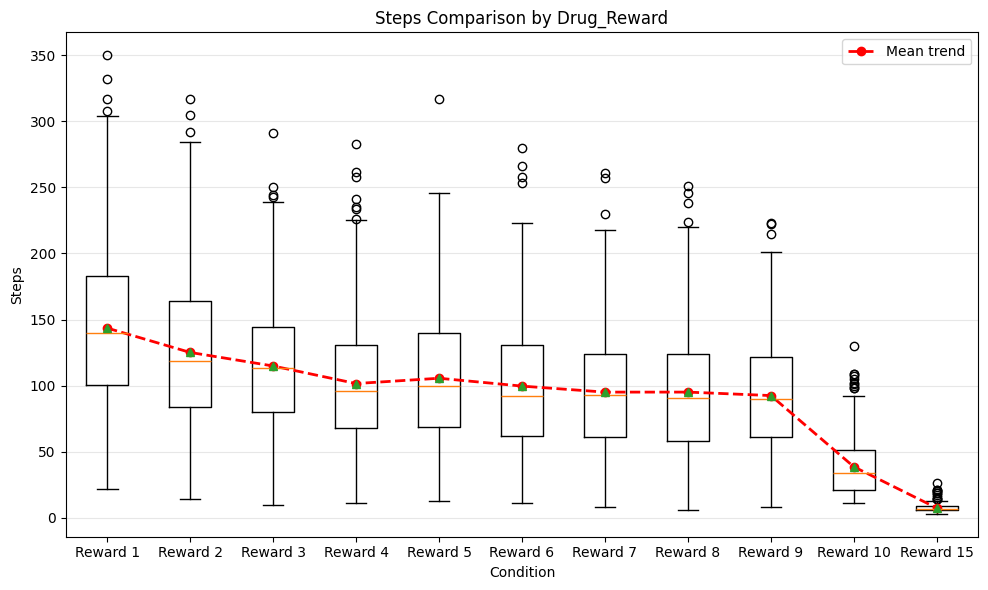

In [12]:
plot_condition_boxplots(results_path, 'ENG_PEN_FAC9_G1')

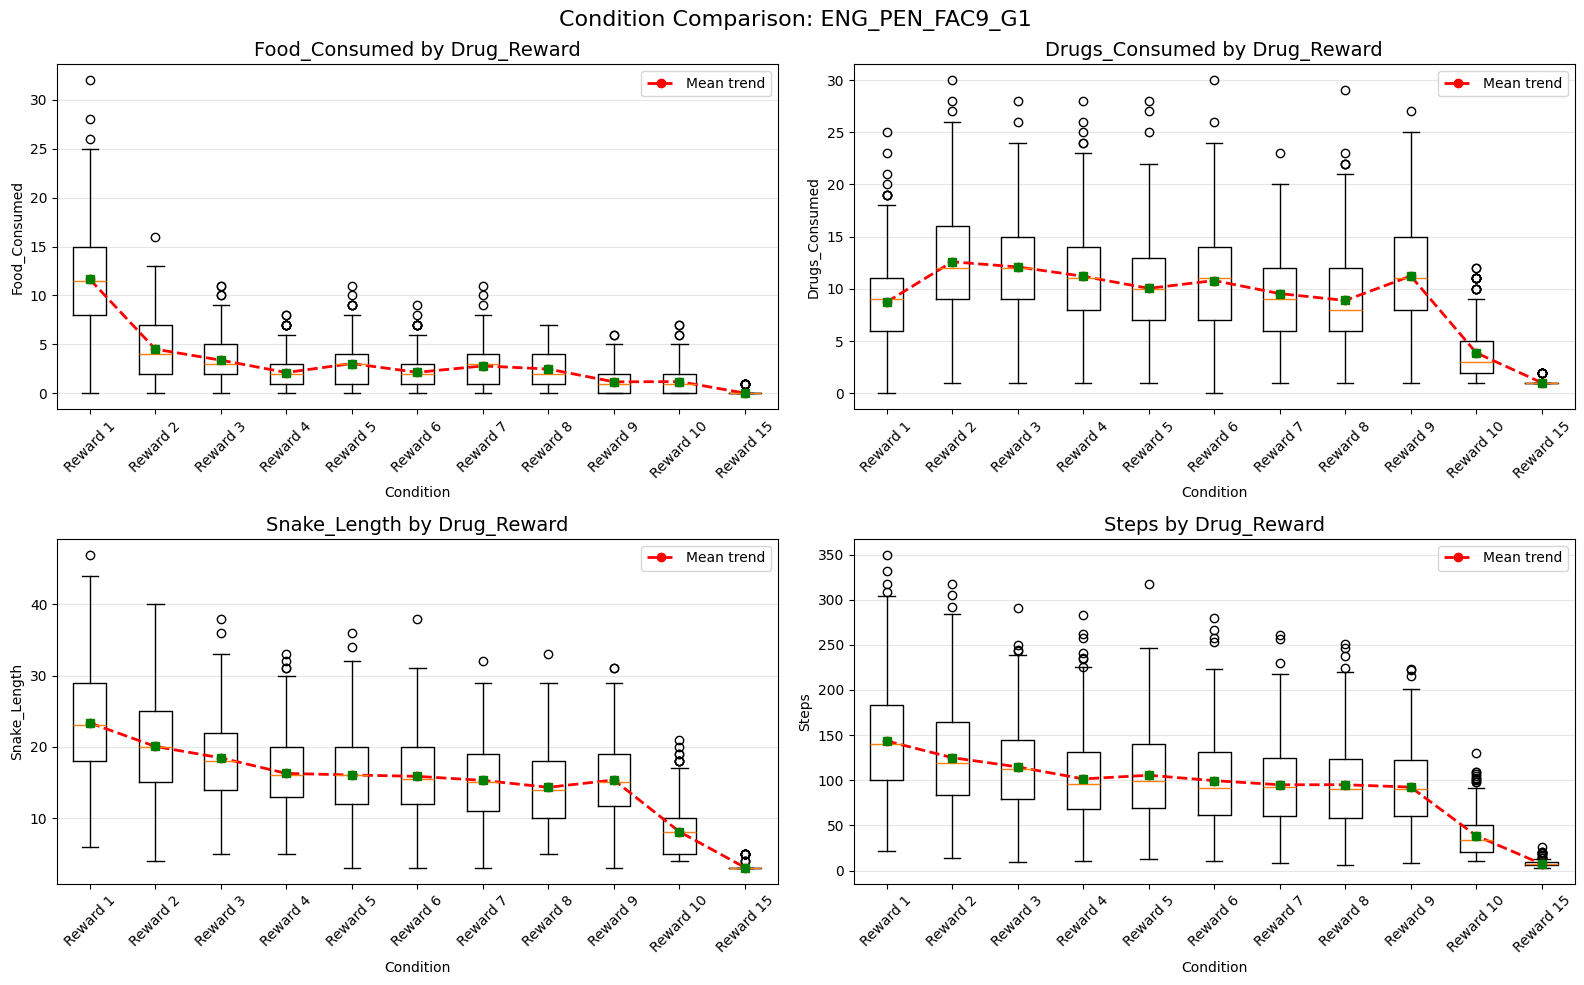

In [13]:
plot_condition_boxplots_grid(results_path, 'ENG_PEN_FAC9_G1')

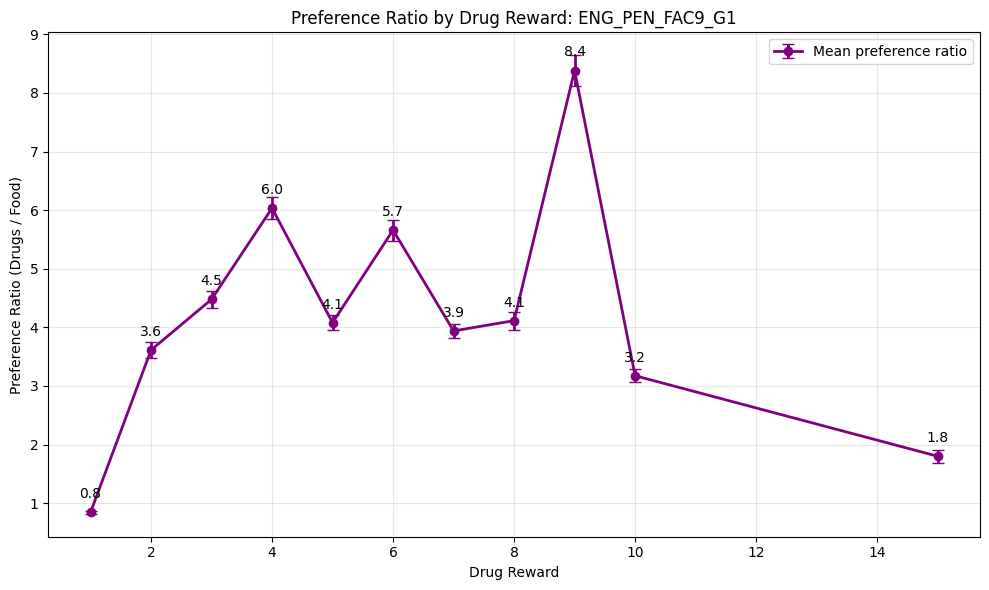

In [14]:
plot_preference_ratio_by_reward(results_path, "ENG_PEN_FAC9_G1")


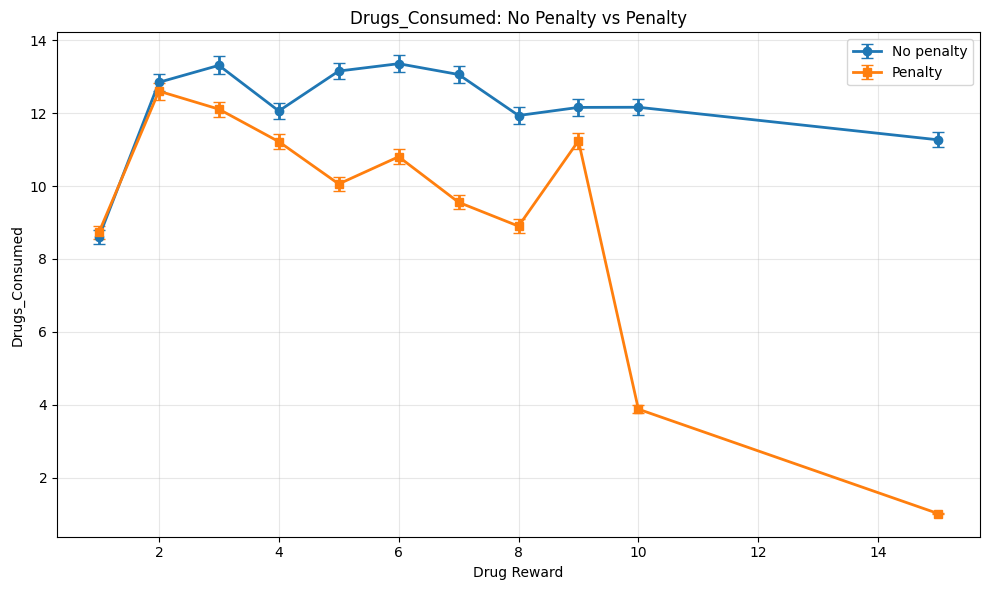

In [15]:

no_penalty_path = Path("../Results/Drugs_Energy_No_Penalty_G1")
penalty_path = Path("../Results/Drugs_Energy_Yes_Penalty_G1")

plot_penalty_vs_no_penalty_metric(
    no_penalty_path,
    "ENG_NO_PEN_G1",
    penalty_path,
    "ENG_PEN_FAC9_G1",
)

In [16]:

# ----- LOADING -----
def extract_drug_reward(path, condition_suffix=""):
    """
    The extract_drug_reward function is designed to parse the name of a file (provided as a pathlib.Path object) 
    and extract the numeric "drug reward" value associated with that file's experiment.

    "EVAL_DRUG_R25_NO_GROWTH_Q_EP15k_TIME_XXX"
    Returns --> 25

    Input:
    - path = Path to the CSV file
    - condition_suffix = 
    Output:
    - reward_value
    """
    if condition_suffix:
        pattern = rf"(?:DRUG_R|drug_reward_)(\d+)_{re.escape(condition_suffix)}"
    else:
        pattern = r"(?:DRUG_R|drug_reward_)(\d+)"
        
    match = re.search(pattern, path.stem, flags=re.IGNORECASE)
    return int(match.group(1)) if match else None

def load_evaluation_results(results_folder, condition_suffix):
    results_folder = Path(results_folder)
    # Gather list of csv files
    csv_files = [csv_file for csv_file in results_folder.glob("*.csv")
        if extract_drug_reward(Path(csv_file), condition_suffix) is not None]
    
    csv_files_list = sorted(csv_files, key=lambda csv_file: extract_drug_reward(csv_file, condition_suffix))

    if len(csv_files_list) == 0:
        raise FileNotFoundError(
            f"No drug evaluation CSV files with suffix '{condition_suffix}' found in: {results_folder}"
        )

    all_dfs = []
    for csv_file in csv_files:
        reward = extract_drug_reward(csv_file, condition_suffix)
        df = pd.read_csv(csv_file)
        df["Drug_Reward"] = reward
        all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_penalty_comparison_grid(
    no_penalty_folder,
    no_penalty_suffix,
    penalty_folder,
    penalty_suffix,
    metrics=None,
    ylims=None,
):
    """
    Plots a 2x2 grid comparing no-penalty vs penalty conditions.
    Uses mean values only, with trend lines.
    """
    no_penalty_df = load_evaluation_results(no_penalty_folder, no_penalty_suffix)
    penalty_df = load_evaluation_results(penalty_folder, penalty_suffix)

    if metrics is None:
        metrics = [
            "Food_Consumed",
            "Drugs_Consumed",
            "Snake_Length",
            "Steps",
        ]

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        if metric not in no_penalty_df.columns:
            print(f"Warning: Metric '{metric}' not found in no-penalty data.")
            ax.set_visible(False)
            continue

        if metric not in penalty_df.columns:
            print(f"Warning: Metric '{metric}' not found in penalty data.")
            ax.set_visible(False)
            continue

        no_penalty_summary = (
            no_penalty_df
            .groupby("Drug_Reward")[metric]
            .mean()
            .reset_index()
            .sort_values("Drug_Reward")
        )

        penalty_summary = (
            penalty_df
            .groupby("Drug_Reward")[metric]
            .mean()
            .reset_index()
            .sort_values("Drug_Reward")
        )

        common_rewards = sorted(
            set(no_penalty_summary["Drug_Reward"])
            .intersection(set(penalty_summary["Drug_Reward"]))
        )

        no_penalty_summary = no_penalty_summary[
            no_penalty_summary["Drug_Reward"].isin(common_rewards)
        ]

        penalty_summary = penalty_summary[
            penalty_summary["Drug_Reward"].isin(common_rewards)
        ]

        ax.plot(
            no_penalty_summary["Drug_Reward"],
            no_penalty_summary[metric],
            marker="o",
            linewidth=2,
            label="No penalty",
        )

        ax.plot(
            penalty_summary["Drug_Reward"],
            penalty_summary[metric],
            marker="s",
            linewidth=2,
            label="Penalty",
        )

        if ylims is not None and metric in ylims:
            ax.set_ylim(ylims[metric])

        ax.set_title(f"{metric}: No Penalty vs Penalty")
        ax.set_xlabel("Drug Reward")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.legend()

    for ax in axes[len(metrics):]:
        ax.set_visible(False)

    fig.suptitle("Energy Condition Comparison: No Penalty vs Penalty", fontsize=16)
    plt.tight_layout()
    plt.show()


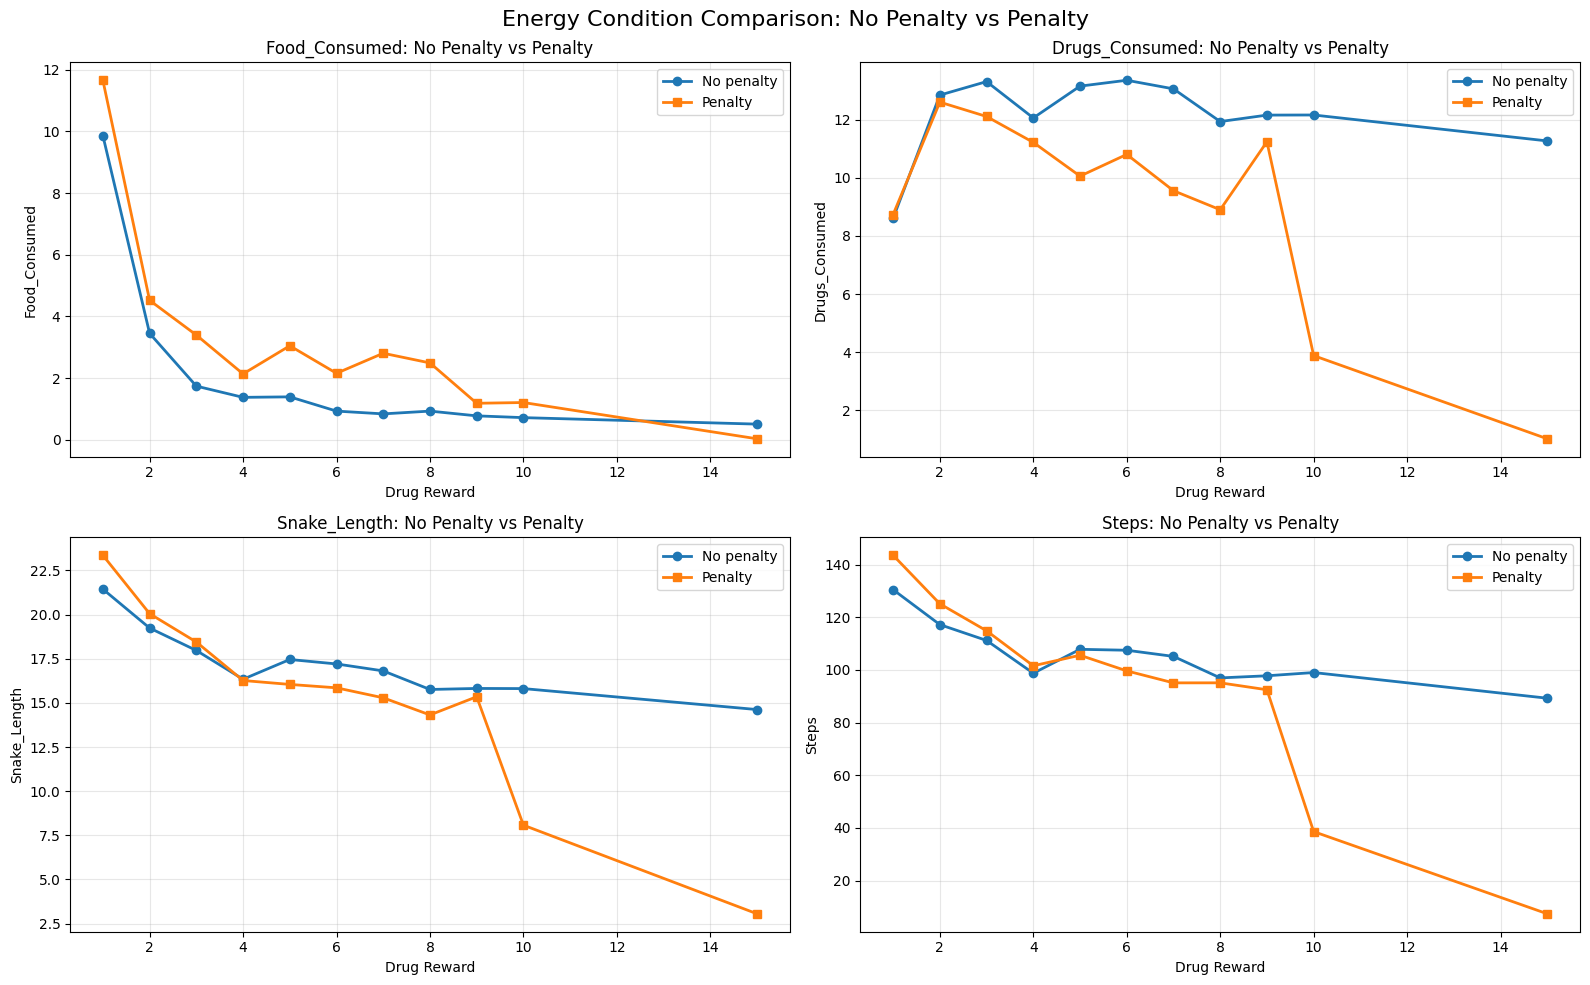

In [22]:
no_penalty_path = Path("../Results/Drugs_Energy_No_Penalty_G1")
penalty_path = Path("../Results/Drugs_Energy_Yes_Penalty_G1")

plot_penalty_comparison_grid(
    no_penalty_path,
    "ENG_NO_PEN_G1",
    penalty_path,
    "ENG_PEN_FAC9_G1",
)
